In [1]:
import sys
import os
from pathlib import Path

import pandas as pd

In [47]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

In [2]:
os.getcwd()

'E:\\KAGGLE\\kaggle_submissions\\s05e03_binary_prediction_with_a_rainfall_dataset'

In [3]:
path = Path(os.getcwd())
parent_folder = path.parent.resolve()
parent_folder

WindowsPath('E:/KAGGLE/kaggle_submissions')

In [4]:
sys.path.append(str(parent_folder))

In [5]:
from kaggle_utils import (load_kaggle_creds, download_competition_data,
        find_target_variable,
        find_id_variable)
                    

In [6]:
kaggle_cred_file = r'E:\env\KAGGLE_KEY\kaggle.json'
load_kaggle_creds(kaggle_cred_file)

In [7]:
competition = 'playground-series-s5e3'
download_competition_data(competition)

Data files already found


In [21]:
data_location = os.path.join(os.getcwd(), 'data')
target = find_target_variable(data_location)[0]

target

'rainfall'

In [12]:
id_col = find_id_variable(data_location)

id_col

['id']

In [10]:
train_file = os.path.join(data_location, 'train.csv')
test_file = os.path.join(data_location, 'test.csv')

train_df= pd.read_csv(train_file)
test_df= pd.read_csv(test_file)

In [13]:
train_df = train_df.drop(columns = id_col)

In [14]:
train_df.head()

,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed,rainfall
0,1,1017.4,21.2,20.6,19.9,19.4,87.0,88.0,1.1,60.0,17.2,1
1,2,1019.5,16.2,16.9,15.8,15.4,95.0,91.0,0.0,50.0,21.9,1
2,3,1024.1,19.4,16.1,14.6,9.3,75.0,47.0,8.3,70.0,18.1,1
3,4,1013.4,18.1,17.8,16.9,16.8,95.0,95.0,0.0,60.0,35.6,1
4,5,1021.8,21.3,18.4,15.2,9.6,52.0,45.0,3.6,40.0,24.8,0


In [16]:
train_df.describe().round(2)

,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed,rainfall
count,2190.00,2190.00,2190.00,2190.00,2190.00,2190.00,2190.00,2190.00,2190.00,2190.00,2190.00,2190.00
mean,179.95,1013.60,26.37,23.95,22.17,20.45,82.04,75.72,3.74,104.86,21.80,0.75
std,105.20,5.66,5.65,5.22,5.06,5.29,7.80,18.03,3.63,80.00,9.90,0.43
min,1.00,999.00,10.40,7.40,4.00,-0.30,39.00,2.00,0.00,10.00,4.40,0.00
25%,89.00,1008.60,21.30,19.30,17.70,16.80,77.00,69.00,0.40,40.00,14.12,1.00
50%,178.50,1013.00,27.80,25.50,23.85,22.15,82.00,83.00,2.40,70.00,20.50,1.00
75%,270.00,1017.78,31.20,28.40,26.40,25.00,88.00,88.00,6.80,200.00,27.90,1.00
max,365.00,1034.60,36.00,31.50,29.80,26.70,98.00,100.00,12.10,300.00,59.50,1.00


In [18]:
import matplotlib.pyplot as plt

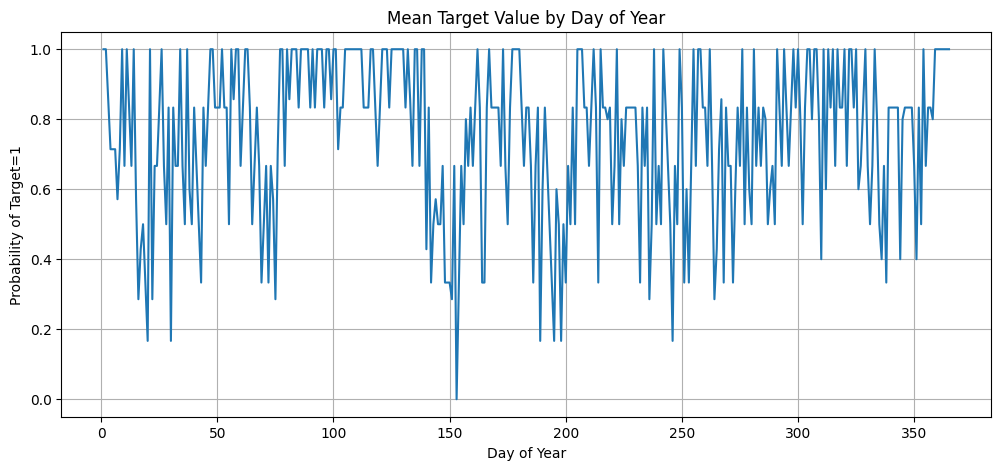

In [22]:
day_effect = train_df.groupby('day')[target].mean()

plt.figure(figsize=(12, 5))
day_effect.plot()
plt.title('Mean Target Value by Day of Year')
plt.xlabel('Day of Year')
plt.ylabel('Probability of Target=1')
plt.grid(True)
plt.show()

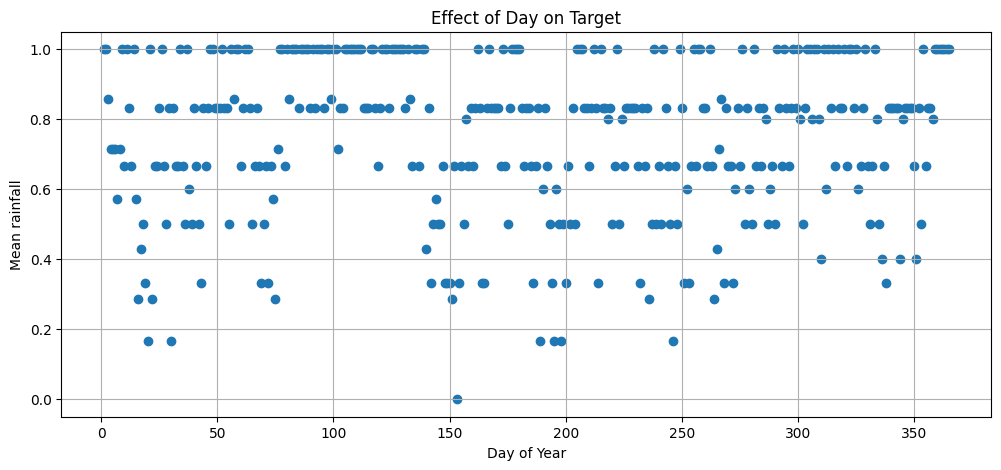

In [51]:
import matplotlib.pyplot as plt

day_effect = train_df.groupby('day')[target].mean()

plt.figure(figsize=(12, 5))
plt.scatter(day_effect.index, day_effect.values)
plt.xlabel('Day of Year')
plt.ylabel(f'Mean {target}')
plt.title('Effect of Day on Target')
plt.grid(True)
plt.show()


In [24]:
from sklearn.feature_selection import mutual_info_classif

X = train_df[['day']]
y = train_df[target]

mi = mutual_info_classif(X, y, discrete_features=True)
print(f"Mutual Information Score for 'day_of_year': {mi[0]:.4f}")


Mutual Information Score for 'day_of_year': 0.1597


In [32]:
def check_mutual_info(df, ind_vars, target_var):
    X = train_df[ind_vars]
    y = train_df[target]
    mi = mutual_info_classif(X, y, discrete_features=False)

    col_wise_mi = {col: info for col, info in zip(X.columns, mi)}
    print(f"Mutual Information Scores:")
    for col, info in col_wise_mi.items():
        print(col, '\t-->\t', f"{info:.4f}")

    return col_wise_mi

In [33]:
ind_vars = [i for i in train_df.columns if i != target]
check_mutual_info(train_df, ind_vars, target_var=target)

Mutual Information Scores:
day 	-->	 0.0702
pressure 	-->	 0.0123
maxtemp 	-->	 0.0123
temparature 	-->	 0.0350
mintemp 	-->	 0.0136
dewpoint 	-->	 0.0042
humidity 	-->	 0.1408
cloud 	-->	 0.2085
sunshine 	-->	 0.1713
winddirection 	-->	 0.0057
windspeed 	-->	 0.0000


{'day': np.float64(0.07022940612972706),
 'pressure': np.float64(0.01227483009916086),
 'maxtemp': np.float64(0.012255214225843414),
 'temparature': np.float64(0.034977798996185916),
 'mintemp': np.float64(0.013574274239021245),
 'dewpoint': np.float64(0.004196870339011172),
 'humidity': np.float64(0.14084599431688072),
 'cloud': np.float64(0.2085366706797367),
 'sunshine': np.float64(0.17125865311353516),
 'winddirection': np.float64(0.005709485062459274),
 'windspeed': np.float64(0.0)}

In [35]:
from sklearn.ensemble import RandomForestClassifier
for feature in ind_vars:
    features = [feature]  # or include others too
    X = train_df[features]
    y = train_df[target]
    
    clf = RandomForestClassifier()
    clf.fit(X, y)
    print(f"Feature importance for '{feature}': {clf.feature_importances_[0]:.4f}")


Feature importance for 'day': 1.0000
Feature importance for 'pressure': 1.0000
Feature importance for 'maxtemp': 1.0000
Feature importance for 'temparature': 1.0000
Feature importance for 'mintemp': 1.0000
Feature importance for 'dewpoint': 1.0000
Feature importance for 'humidity': 1.0000
Feature importance for 'cloud': 1.0000
Feature importance for 'sunshine': 1.0000
Feature importance for 'winddirection': 1.0000
Feature importance for 'windspeed': 1.0000


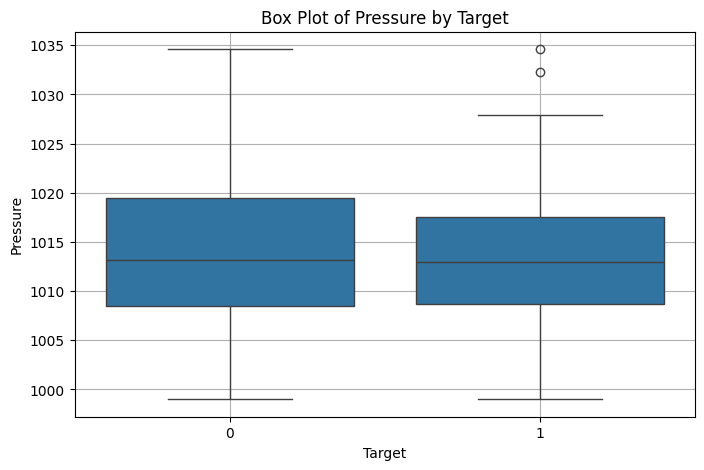

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

# Box Plot
plt.figure(figsize=(8, 5))
sns.boxplot(x=target, y='pressure', data=train_df)
plt.title('Box Plot of Pressure by Target')
plt.xlabel('Target')
plt.ylabel('Pressure')
plt.grid(True)
plt.show()

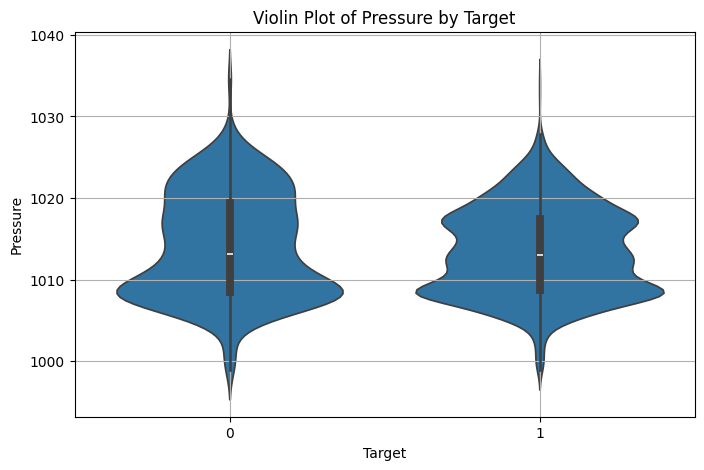

In [39]:
# Violin Plot
plt.figure(figsize=(8, 5))
sns.violinplot(x=target, y='pressure', data=train_df)
plt.title('Violin Plot of Pressure by Target')
plt.xlabel('Target')
plt.ylabel('Pressure')
plt.grid(True)
plt.show()

C:\Users\yash\AppData\Local\Temp\ipykernel_35392\1519781528.py:4: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data=train_df[train_df[target] == 0], x='pressure', label='Target = 0', shade=True, linewidth=2)
C:\Users\yash\AppData\Local\Temp\ipykernel_35392\1519781528.py:7: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data=train_df[train_df[target] == 1], x='pressure', label='Target = 1', shade=True, linewidth=2)


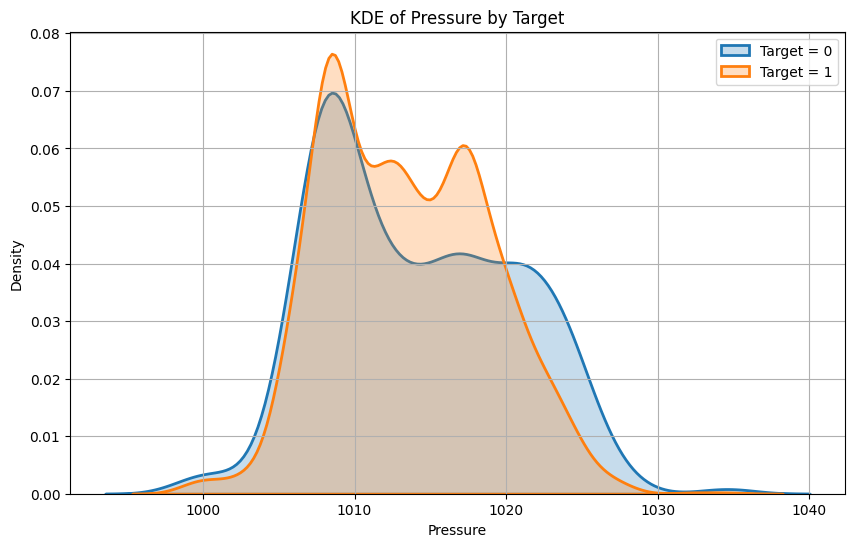

In [42]:
plt.figure(figsize=(10, 6))

# KDE for target = 0
sns.kdeplot(data=train_df[train_df[target] == 0], x='pressure', label='Target = 0', shade=True, linewidth=2)

# KDE for target = 1
sns.kdeplot(data=train_df[train_df[target] == 1], x='pressure', label='Target = 1', shade=True, linewidth=2)

plt.title('KDE of Pressure by Target')
plt.xlabel('Pressure')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.show()

Overlap Area: 0.8735 (1 = total overlap, 0 = no overlap)
KL(rainfall=0 || rainfall=1): 1.7199
KL(rainfall=1 || rainfall=0): 1.4424


C:\Users\yash\AppData\Local\Temp\ipykernel_35392\671903184.py:24: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  overlap = np.trapz(np.minimum(kde_0_vals, kde_1_vals), x)
C:\Users\yash\AppData\Local\Temp\ipykernel_35392\671903184.py:28: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  p0 = kde_0_vals / np.trapz(kde_0_vals, x)
C:\Users\yash\AppData\Local\Temp\ipykernel_35392\671903184.py:29: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  p1 = kde_1_vals / np.trapz(kde_1_vals, x)


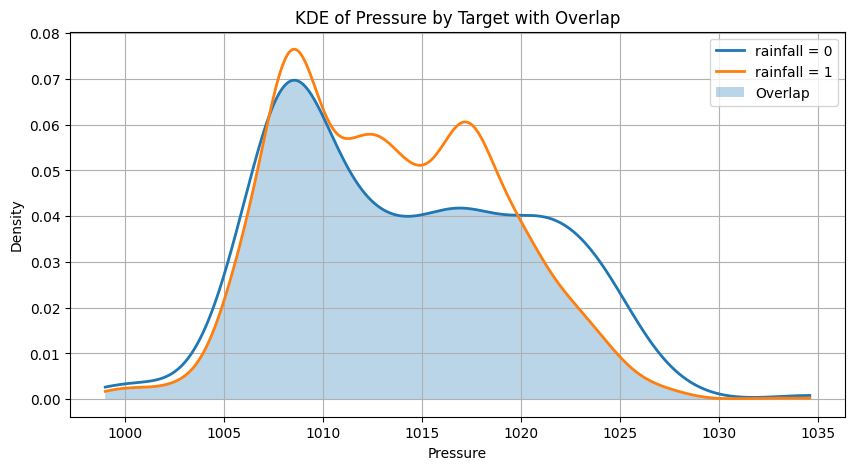

In [43]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from scipy.special import rel_entr

# Example: target = 'label' or whatever your column name is
# Make sure this line exists in your code:
# target = 'your_target_column_name'

# Get the pressure values for each class using the variable
pressure_0 = train_df[train_df[target] == 0]['pressure']
pressure_1 = train_df[train_df[target] == 1]['pressure']

# Define KDEs
kde_0 = gaussian_kde(pressure_0)
kde_1 = gaussian_kde(pressure_1)

# Define common evaluation grid
x = np.linspace(min(train_df['pressure']), max(train_df['pressure']), 1000)
kde_0_vals = kde_0(x)
kde_1_vals = kde_1(x)

# Calculate overlap
overlap = np.trapz(np.minimum(kde_0_vals, kde_1_vals), x)
print(f"Overlap Area: {overlap:.4f} (1 = total overlap, 0 = no overlap)")

# Normalize densities
p0 = kde_0_vals / np.trapz(kde_0_vals, x)
p1 = kde_1_vals / np.trapz(kde_1_vals, x)

# Add small epsilon to avoid log(0)
epsilon = 1e-10
p0 += epsilon
p1 += epsilon

# KL divergence both ways
kl_0_1 = np.sum(rel_entr(p0, p1))
kl_1_0 = np.sum(rel_entr(p1, p0))

print(f"KL({target}=0 || {target}=1): {kl_0_1:.4f}")
print(f"KL({target}=1 || {target}=0): {kl_1_0:.4f}")

# Plot the distributions and overlap
plt.figure(figsize=(10, 5))
plt.plot(x, kde_0_vals, label=f'{target} = 0', linewidth=2)
plt.plot(x, kde_1_vals, label=f'{target} = 1', linewidth=2)
plt.fill_between(x, np.minimum(kde_0_vals, kde_1_vals), alpha=0.3, label='Overlap')
plt.title('KDE of Pressure by Target with Overlap')
plt.xlabel('Pressure')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.show()


In [44]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde
from scipy.special import rel_entr

def analyze_feature_distribution(df, feature, target, visualize=True):
    """
    Computes Overlap Area and KL Divergence between target classes for a given feature.
    
    Parameters:
        df (pd.DataFrame): The input DataFrame.
        feature (str): The name of the feature to analyze.
        target (str): The name of the binary target variable.
        visualize (bool): Whether to display a KDE plot with overlap.
    
    Returns:
        dict: Contains feature name, overlap area, KL divergence (both directions).
    """
    # Get the unique values in the target column (to handle any labels)
    target_classes = df[target].unique()
    if len(target_classes) != 2:
        raise ValueError(f"Target variable must be binary. Found {len(target_classes)} unique values: {target_classes}")

    # Get values for both classes dynamically
    values_0 = df[df[target] == target_classes[0]][feature]
    values_1 = df[df[target] == target_classes[1]][feature]

    # Remove NaNs
    values_0 = values_0.dropna()
    values_1 = values_1.dropna()

    kde_0 = gaussian_kde(values_0)
    kde_1 = gaussian_kde(values_1)

    x = np.linspace(min(df[feature]), max(df[feature]), 1000)
    kde_0_vals = kde_0(x)
    kde_1_vals = kde_1(x)

    # Overlap area
    overlap = np.trapz(np.minimum(kde_0_vals, kde_1_vals), x)

    # Normalize densities
    p0 = kde_0_vals / np.trapz(kde_0_vals, x)
    p1 = kde_1_vals / np.trapz(kde_1_vals, x)
    epsilon = 1e-10
    p0 += epsilon
    p1 += epsilon

    # KL divergence
    kl_0_1 = np.sum(rel_entr(p0, p1))
    kl_1_0 = np.sum(rel_entr(p1, p0))

    # Visualization
    if visualize:
        plt.figure(figsize=(10, 5))
        sns.lineplot(x=x, y=kde_0_vals, label=f'{target}={target_classes[0]}', linewidth=2)
        sns.lineplot(x=x, y=kde_1_vals, label=f'{target}={target_classes[1]}', linewidth=2)
        plt.fill_between(x, np.minimum(kde_0_vals, kde_1_vals), alpha=0.3, label='Overlap')
        plt.title(f'KDE of {feature} by {target} with Overlap')
        plt.xlabel(feature)
        plt.ylabel('Density')
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    return {
        'feature': feature,
        'overlap_area': round(overlap, 4),
        f'kl({target}={target_classes[0]}||{target_classes[1]})': round(kl_0_1, 4),
        f'kl({target_classes[1]}||{target_classes[0]})': round(kl_1_0, 4)
    }


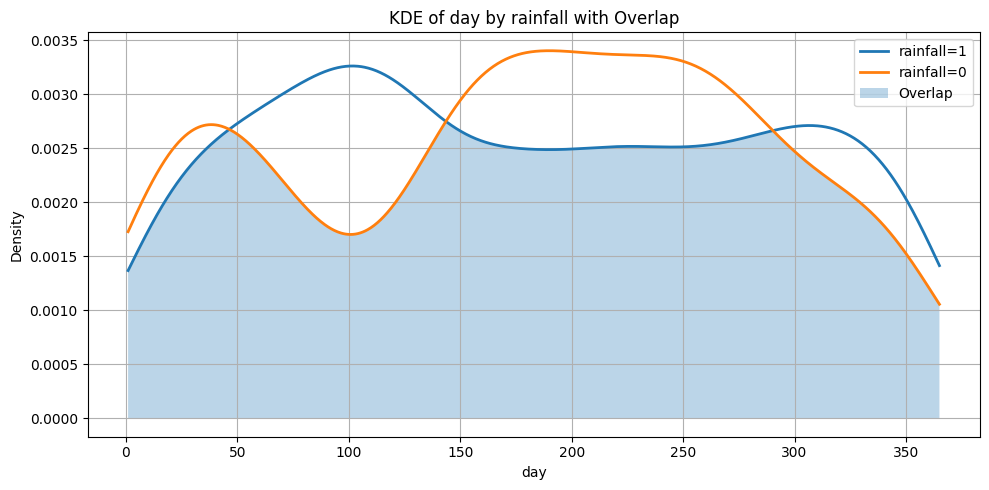

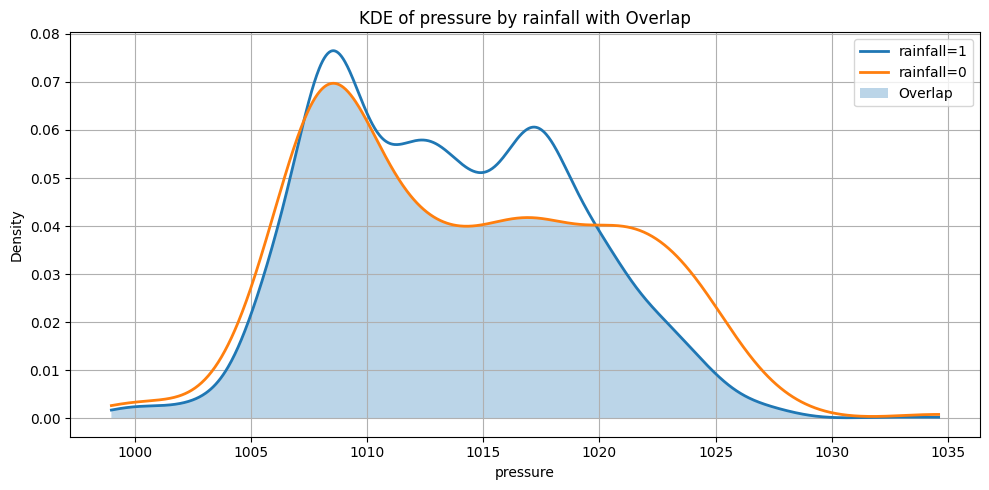

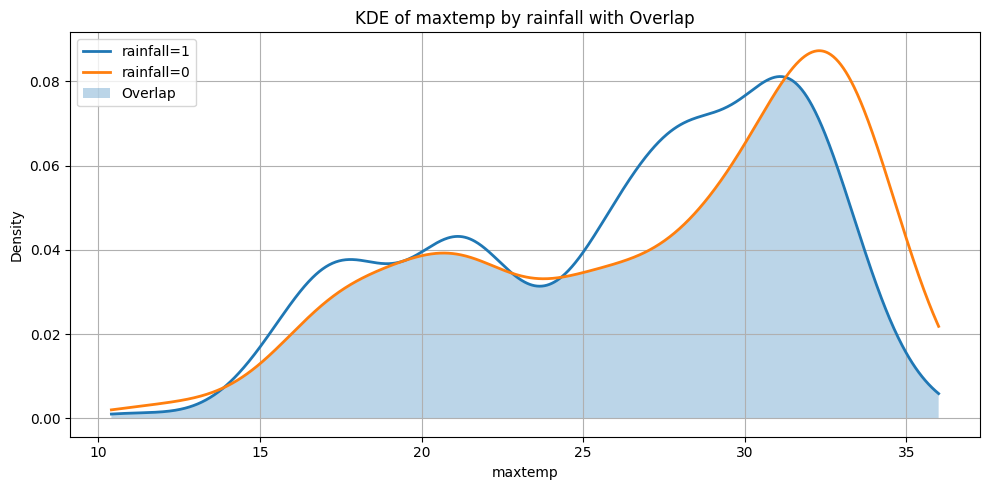

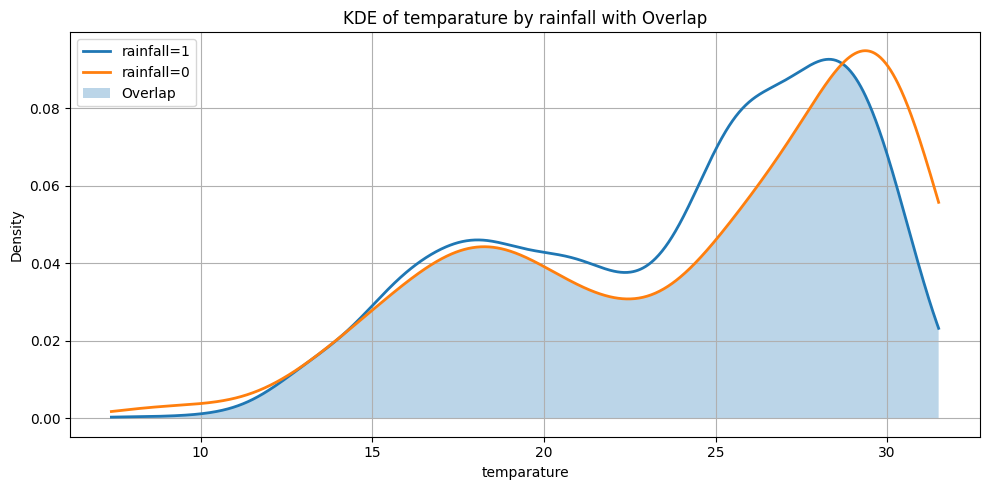

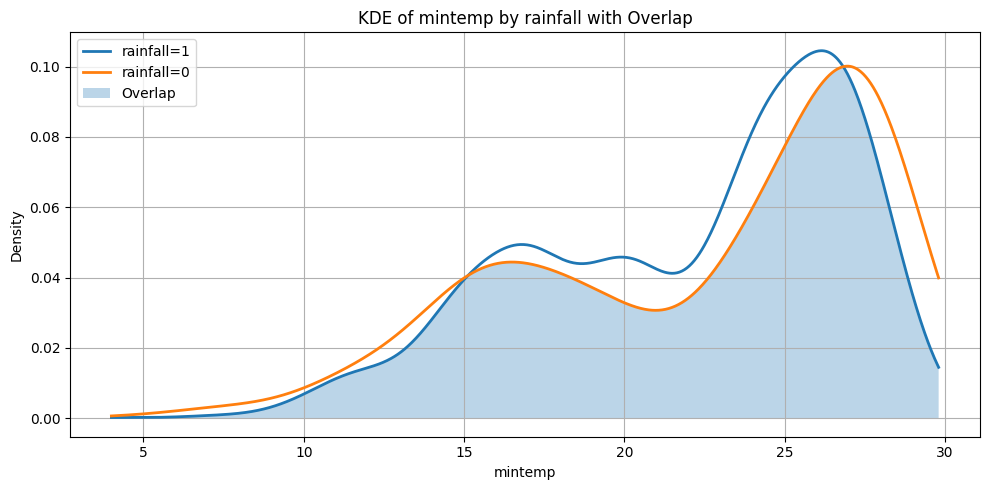

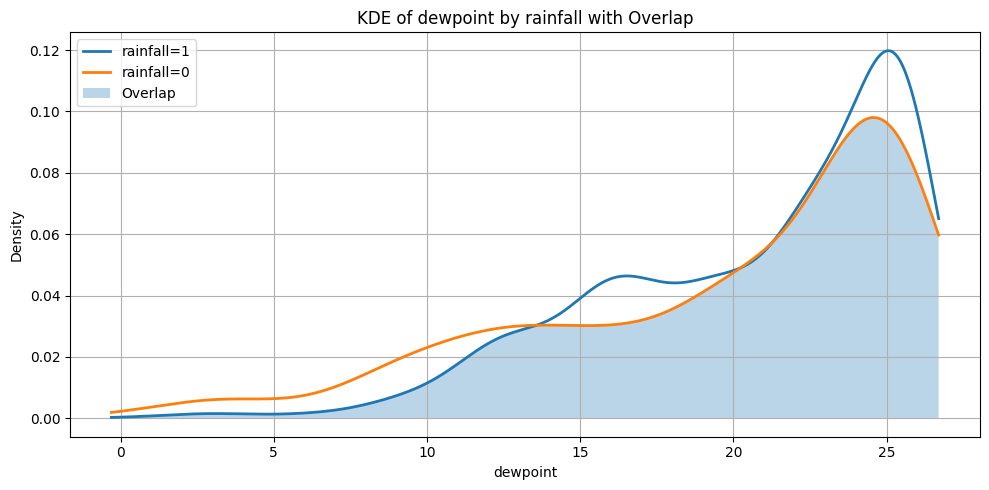

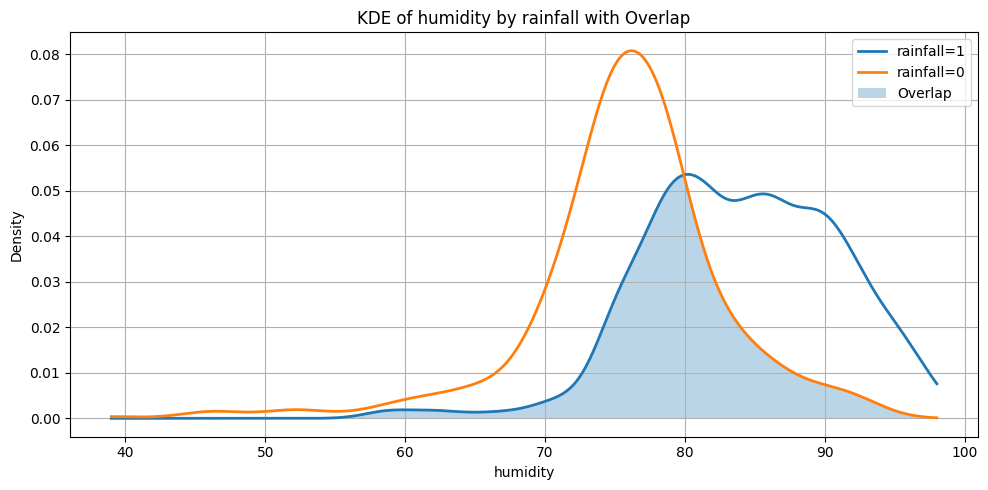

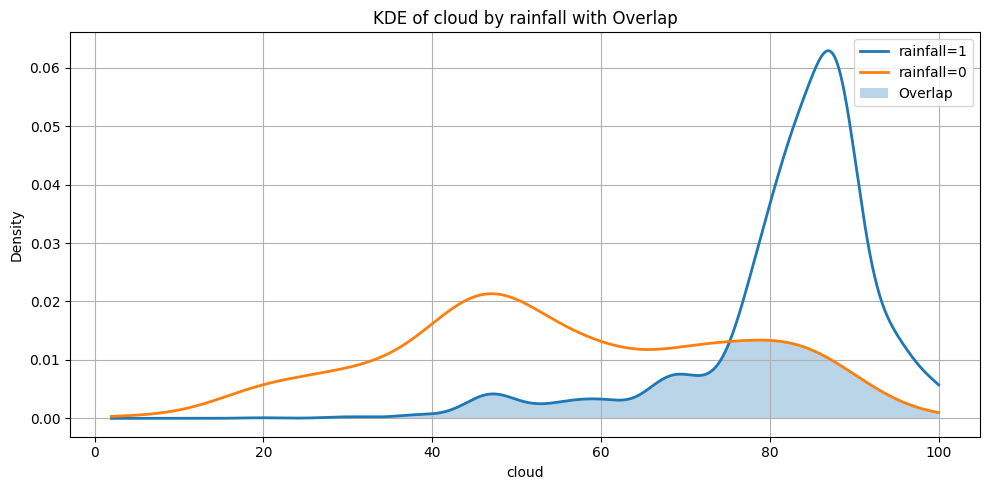

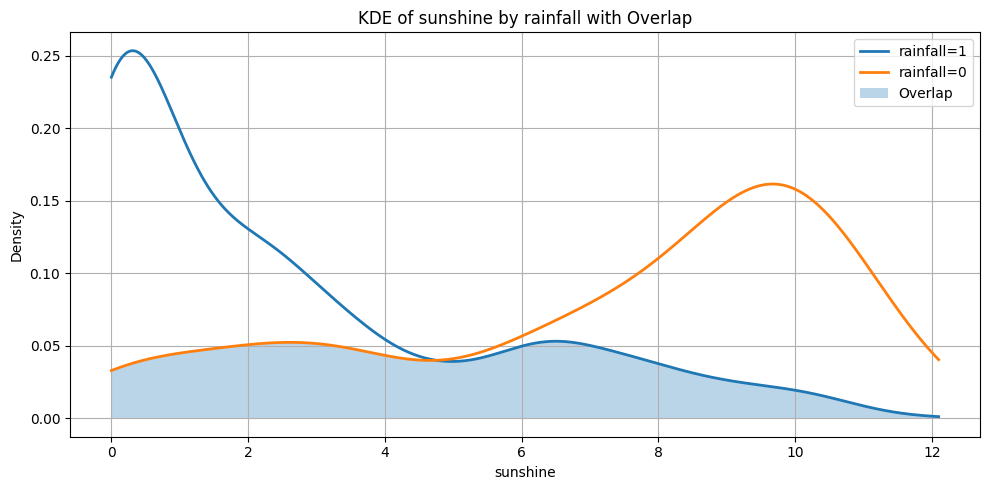

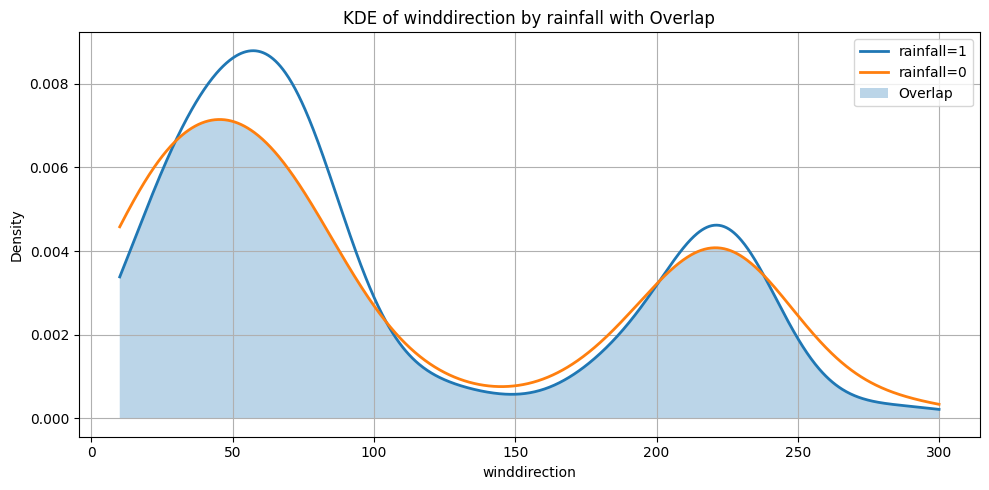

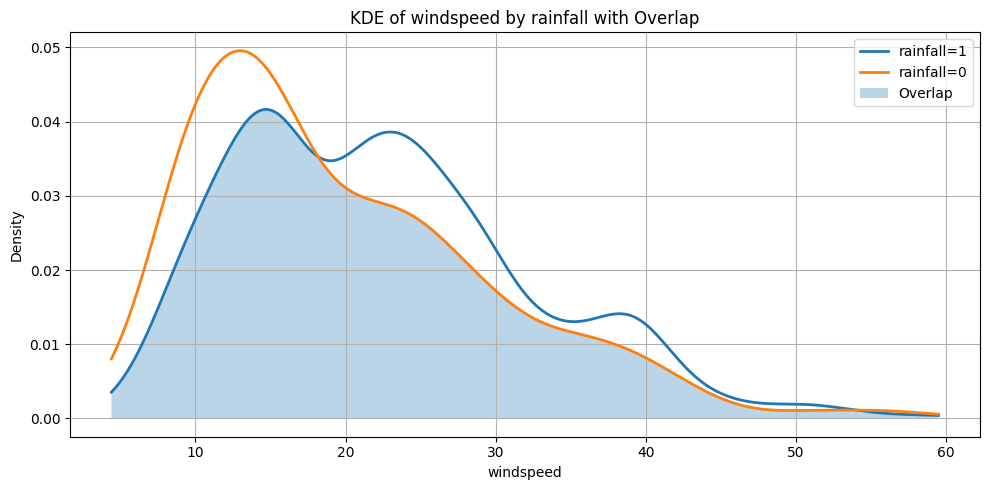

In [49]:
# Specify your target column
target = 'rainfall'  # or whatever your binary column is, like 'yes/no'

# List of continuous features to evaluate
features_to_check = ind_vars

# Set visualize to False to just collect stats
results = []

for feature in features_to_check:
    result = analyze_feature_distribution(train_df, feature, target, visualize=True)
    results.append(result)

In [50]:
# Convert results to a DataFrame
import pandas as pd
results_df = pd.DataFrame(results)
print(results_df)

          feature  overlap_area  kl(rainfall=1||0)  kl(0||1)
0             day        0.8232             0.1204    0.1131
1        pressure        0.8735             1.4424    1.7199
2         maxtemp        0.8603             2.1640    2.5561
3     temparature        0.8605             1.4096    1.7039
4         mintemp        0.8697             1.3685    1.6317
5        dewpoint        0.8360             1.8885    2.5838
6        humidity        0.5233            12.6545   14.7054
7           cloud        0.3696            10.7429   15.8317
8        sunshine        0.4412            64.7148   72.7972
9   winddirection        0.8433             0.0728    0.0800
10      windspeed        0.8598             0.8269    0.8827
